# 02. Event Studies

A two-period difference-in-differences estimate gives one average post-treatment effect. That is often too blunt for real decisions. Product rollouts ramp up. Pricing changes can have an immediate spike followed by adaptation. Operations interventions may take months to affect retention. Some policies even create anticipation before the official start date.

An event study extends DiD by replacing one post-treatment indicator with a set of relative-time indicators. Instead of asking only "what was the average post effect?", it asks "what happened one month before rollout, at launch, one month after, two months after, and so on?"


## Learning Goals

By the end of this notebook, you should be able to:

- Explain the relationship between DiD and event-study regressions.
- Construct relative-time indicators for leads and lags.
- Estimate dynamic treatment effects with unit and time fixed effects.
- Interpret the omitted reference period.
- Use event-study leads as pre-trend diagnostics without overclaiming what they prove.
- Compare dynamic event-study estimates with a single average DiD estimate.
- Diagnose non-parallel trends and anticipation effects.
- Convert an event-study plot into an industry-facing rollout narrative.


In [1]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings

import graphviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)

from notebooks._shared.display import smart_display

In [2]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """
    Create a styled Graphviz causal or design diagram for the lecture.
    
    Idea:
        The diagram makes assumptions, assignment mechanisms, and diagnostic workflows visible before the code estimates an effect.
    
    Args:
        edges: Directed edges from source node to target node in the causal or design diagram.
        title: Title displayed on the Graphviz or Matplotlib figure.
        node_colors: Optional mapping from node labels to fill colors.
        rankdir: Graphviz layout direction, such as left-to-right or top-to-bottom.
    
    Returns:
        graphviz.Digraph: Renderable diagram object for display in the notebook.
    """
    graph = graphviz.Digraph(format="svg")
    graph.attr(rankdir=rankdir, bgcolor="white", pad="0.2")
    graph.attr("node", shape="box", style="rounded,filled", color="#334155", fontname="Helvetica")
    graph.attr("edge", color="#475569", arrowsize="0.8")

    node_colors = node_colors or {}
    nodes = sorted({node for edge in edges for node in edge[:2]})
    for node in nodes:
        graph.node(node, fillcolor=node_colors.get(node, "#eef2ff"))

    for edge in edges:
        if len(edge) == 2:
            graph.edge(edge[0], edge[1])
        else:
            graph.edge(edge[0], edge[1], label=edge[2])

    if title:
        graph.attr(label=title, labelloc="t", fontsize="18", fontname="Helvetica-Bold")
    return graph


def event_effect(event_time):
    """
    Return the true treatment effect at a given event time in the event-study simulation.
    
    Idea:
        The effect path lets the notebook compare estimated event-time coefficients with the known dynamic response after rollout.
    
    Args:
        event_time: Time measured relative to treatment adoption or rollout.
    
    Returns:
        float: True treatment effect for the requested relative time.
    """
    if event_time < 0:
        return 0.0
    effect_path = {
        0: 1.5,
        1: 3.0,
        2: 5.0,
        3: 6.4,
        4: 7.0,
        5: 7.2,
        6: 7.2,
        7: 7.1,
        8: 7.0,
    }
    return effect_path.get(event_time, 7.0)


def event_term(event_time):
    """Convert an event-time value into the safe formula term used by statsmodels.

    Args:
        event_time: Time relative to treatment adoption or intervention.

    Returns:
        str: Formula-safe event-time coefficient name.
    """
    return f"event_m{abs(event_time)}" if event_time < 0 else f"event_p{event_time}"


def extract_parameter(model, parameter):
    """Extract one model parameter with its uncertainty and p-value.

    Args:
        model: Fitted model object whose parameters or predictions are being used.
        parameter: Model parameter name to extract from a fitted object.

    Returns:
        pandas.Series: Estimate, standard error, interval, and p-value for one parameter.
    """
    ci_low, ci_high = model.conf_int().loc[parameter]
    return pd.Series(
        {
            "estimate": model.params[parameter],
            "std_error": model.bse[parameter],
            "ci_low": ci_low,
            "ci_high": ci_high,
            "p_value": model.pvalues[parameter],
        }
    )


def joint_test_summary(model, terms, label):
    """Summarize a joint Wald test for a set of event-study coefficients.

    Args:
        model: Fitted model object whose parameters or predictions are being used.
        terms: List of model terms that define the prediction design matrix.
        label: Human-readable label for the row or scenario being produced.

    Returns:
        pandas.Series: Joint-test statistic, p-value, and tested terms.
    """
    if not terms:
        return pd.DataFrame({"test": [label], "f_stat": [np.nan], "p_value": [np.nan], "df_num": [0]})
    hypothesis = " = 0, ".join(terms) + " = 0"
    test = model.f_test(hypothesis)
    return pd.DataFrame(
        {
            "test": [label],
            "f_stat": [float(test.fvalue)],
            "p_value": [float(test.pvalue)],
            "df_num": [int(test.df_num)],
        }
    )

## 1. From DiD to Event Studies

The previous notebook estimated a single post-rollout DiD effect:

$$
Y_{it} = \alpha_i + \lambda_t + \tau(D_i \times Post_t) + \epsilon_{it}
$$

An event-study regression replaces the single post indicator with a set of relative-time indicators:

$$
Y_{it} = \alpha_i + \lambda_t + \sum_{k \ne -1} \beta_k \cdot 1[D_i = 1, t - T_i = k] + \epsilon_{it}
$$

where:

- $T_i$ is the rollout time for treated unit $i$.
- $k = t - T_i$ is event time.
- $k < 0$ are **leads**: periods before the event.
- $k \ge 0$ are **lags**: periods at or after the event.
- One event-time period must be omitted as a reference. A common choice is $k = -1$, the last pre-treatment period.

Callaway (2022) describes event studies as a common DiD target for treatment-effect dynamics and pre-testing: pre-treatment event-time estimates should be zero if the parallel-trends assumptions are working in the observed pre-period.


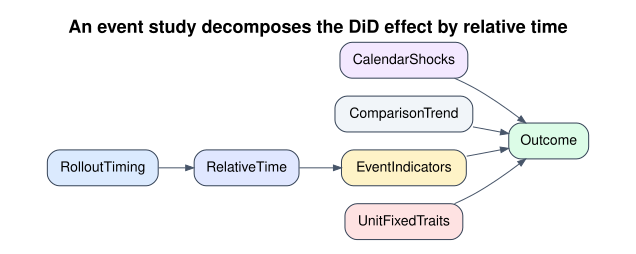

In [3]:
# Organize the calculation into readable steps for the lecture narrative.
make_dag(
    edges=[
        ("RolloutTiming", "RelativeTime"),
        ("RelativeTime", "EventIndicators"),
        ("EventIndicators", "Outcome"),
        ("UnitFixedTraits", "Outcome"),
        ("CalendarShocks", "Outcome"),
        ("ComparisonTrend", "Outcome"),
    ],
    title="An event study decomposes the DiD effect by relative time",
    node_colors={
        "RolloutTiming": "#dbeafe",
        "RelativeTime": "#e0e7ff",
        "EventIndicators": "#fef3c7",
        "Outcome": "#dcfce7",
        "UnitFixedTraits": "#fee2e2",
        "CalendarShocks": "#f3e8ff",
        "ComparisonTrend": "#f1f5f9",
    },
)


The event-study plot has two jobs. First, it shows the dynamic post-rollout response. Second, it shows whether treated units were already moving differently before rollout. Those are related but distinct tasks: a nice-looking pre-period is reassuring, but it is never a proof that the post-period counterfactual is correct. Freyaldenhoven, Hansen, and Shapiro (2019) emphasize that failure to detect pre-trends may reflect limited power, and Roth (2022) warns that conditioning on passing a pre-trend test can distort inference.


## 2. Running Example: A Support Program with Ramp-Up

Continue the regional support-program example. This time, suppose the program does not reach its full effect immediately. The first month is mostly training and workflow adjustment. The next few months accumulate benefit as store teams learn which customers to prioritize.

We will simulate:

- Treated and comparison stores observed for 8 months before and 8 months after rollout.
- Stable store differences absorbed by store fixed effects.
- Calendar shocks absorbed by month fixed effects.
- A dynamic effect path that ramps from a small launch effect to a stable long-run lift.


**Dataset and experiment setup.** The event-study dataset is a store or market panel with observations before and after a support program begins. The treatment effect is dynamic rather than constant: it starts near the rollout date and changes as implementation ramps up. Each row is a unit-month observation with an event time relative to treatment. The simulation includes unit differences, calendar shocks, and known effects by event time. That structure lets the notebook teach leads, lags, reference periods, pre-trend checks, and why the average DiD estimate can hide the shape of the effect path.

In [4]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_event_study_panel(
    n_stores=320,
    months=range(-8, 9),
    seed=4217,
    differential_trend=0.0,
    anticipation=False,
    noise_scale=2.4,
):
    """
    Generate a panel dataset for event-study diagnostics.
    
    Idea:
        The simulation controls adoption timing, anticipation, differential trends, and noise so visual pre-trend checks have a known benchmark.
    
    Args:
        n_stores: Number of stores included in the simulated panel.
        months: Sequence of monthly time periods in the panel simulation.
        seed: Random seed for reproducible simulation or bootstrap draws.
        differential_trend: Extra trend assigned to treated units to create or remove a parallel-trends violation.
        anticipation: Pre-treatment behavioral response added before rollout in the simulation.
        noise_scale: Residual noise scale used in the event-study simulation.
    
    Returns:
        pandas.DataFrame: Store-period panel with event time, treatment status, outcome, and known effect components.
    """
    rng = np.random.default_rng(seed)
    stores = pd.DataFrame({"store_id": np.arange(n_stores)})
    stores["treated_region"] = rng.binomial(1, 0.42, n_stores)
    stores["store_size"] = rng.lognormal(mean=3.3 + 0.08 * stores["treated_region"], sigma=0.35, size=n_stores)
    stores["baseline_loyalty"] = rng.normal(0.15 + 0.32 * stores["treated_region"], 0.75, n_stores)
    stores["competition"] = rng.normal(-0.10 * stores["treated_region"], 1.0, n_stores)

    stores["unit_fe"] = (
        62
        + 0.20 * stores["store_size"]
        + 3.00 * stores["baseline_loyalty"]
        - 1.50 * stores["competition"]
        + 3.30 * stores["treated_region"]
        + rng.normal(0, 4.5, n_stores)
    )

    rows = []
    for _, store in stores.iterrows():
        eps_prev = rng.normal(0, 2.0)
        store_slope = rng.normal(0, 0.07)
        for event_time in months:
            post = int(event_time >= 0)
            common_time = 0.45 * event_time + 1.60 * np.sin((event_time + 8) / 2.5)
            demand_index = 0.35 * store["baseline_loyalty"] + 0.25 * common_time + rng.normal(0, 0.9)
            eps = 0.55 * eps_prev + rng.normal(0, noise_scale)
            eps_prev = eps

            untreated_trend = (0.12 + store_slope + differential_trend * store["treated_region"]) * event_time
            effect = event_effect(event_time) * store["treated_region"]

            if anticipation and store["treated_region"] == 1 and event_time in [-2, -1]:
                effect += 1.2 if event_time == -2 else 2.0

            revenue = (
                store["unit_fe"]
                + common_time
                + untreated_trend
                + 1.50 * demand_index
                + effect
                + eps
            )

            rows.append(
                {
                    "store_id": int(store["store_id"]),
                    "treated_region": int(store["treated_region"]),
                    "month": int(event_time),
                    "event_time": int(event_time),
                    "post": post,
                    "demand_index": demand_index,
                    "revenue": revenue,
                    "true_treatment_effect": effect,
                }
            )

    return pd.DataFrame(rows)


df = simulate_event_study_panel()
true_average_post_effect = df.loc[df["treated_region"].eq(1) & df["post"].eq(1), "true_treatment_effect"].mean()

panel_summary = pd.Series(
    {
        "stores": df["store_id"].nunique(),
        "months": df["month"].nunique(),
        "rows": len(df),
        "treated_store_share": df.drop_duplicates("store_id")["treated_region"].mean(),
        "true_average_post_effect": true_average_post_effect,
    }
).to_frame("value")
smart_display(panel_summary)

,value
stores,320.000
months,17.000
rows,5440.000
treated_store_share,0.425
true_average_post_effect,5.711


In Running Example: A Support Program with Ramp-Up, the table is also evidence about the trend assumption. A convincing pre-period pattern is what lets the post-period gap carry causal weight.

The true average post effect is useful for checking the simulation, but the event study will reveal that this average hides a ramp-up pattern.


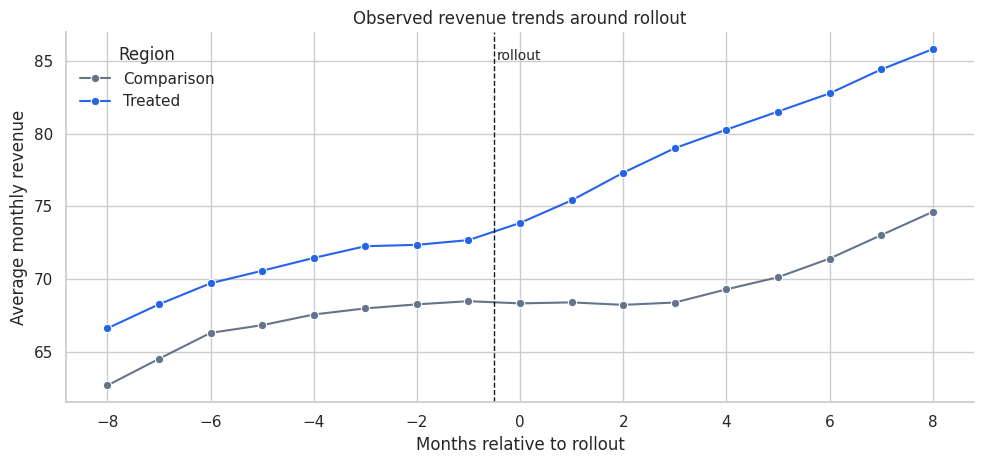

In [5]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
trend = (
    df.groupby(["treated_region", "event_time"], observed=True)["revenue"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4.8))
sns.lineplot(
    data=trend,
    x="event_time",
    y="revenue",
    hue="treated_region",
    marker="o",
    palette={0: "#64748b", 1: "#2563eb"},
    ax=ax,
)
ax.axvline(-0.5, color="#111827", linestyle="--", linewidth=1)
ax.text(-0.45, trend["revenue"].max(), "rollout", ha="left", va="top", fontsize=10)
ax.set_title("Observed revenue trends around rollout")
ax.set_xlabel("Months relative to rollout")
ax.set_ylabel("Average monthly revenue")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=["Comparison", "Treated"], title="Region", frameon=False)
sns.despine(ax=ax)
plt.tight_layout()


The raw trend plot shows the treated region pulling away after rollout. It also gives an initial visual check of pre-period behavior. But raw means still mix together baseline level differences and calendar effects. The event-study regression handles those with fixed effects.


## 3. Creating Event-Time Indicators

For a single rollout cohort, event time is just month relative to rollout. For treated units, each event-time dummy turns on in one relative month. For comparison units, all event-time treatment dummies are zero because they never receive the intervention.

We will omit $k=-1$ as the reference period. Every coefficient is interpreted relative to the treated-comparison difference in the month just before rollout.


In [6]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def add_event_dummies(frame, low=-8, high=8, reference=-1, event_column="event_time"):
    """Add event-time dummy variables for a clean event-study regression.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        low: Lower event-time bound for indicators or bins.
        high: Upper event-time bound for indicators or bins.
        reference: Reference value or omitted event time used for interpretation.
        event_column: Column that stores event time.

    Returns:
        pandas.DataFrame: Copy of the frame with event-time indicators added.
    """
    work = frame.copy()
    event_times = list(range(low, high + 1))
    event_columns = []
    for event_time in event_times:
        if event_time == reference:
            continue
        column = event_term(event_time)
        work[column] = (
            work["treated_region"].eq(1) & work[event_column].eq(event_time)
        ).astype(int)
        event_columns.append(column)
    return work, event_columns, event_times


def fit_event_study(frame, low=-8, high=8, reference=-1, outcome="revenue"):
    """Fit a fixed-effects event-study model over a chosen event-time window.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        low: Lower event-time bound for indicators or bins.
        high: Upper event-time bound for indicators or bins.
        reference: Reference value or omitted event time used for interpretation.
        outcome: Outcome variable name or vector being analyzed.

    Returns:
        tuple: Fitted event-study model and coefficient table.
    """
    work, event_columns, event_times = add_event_dummies(frame, low=low, high=high, reference=reference)
    formula = f"{outcome} ~ " + " + ".join(event_columns) + " + C(store_id) + C(month)"
    model = smf.ols(formula, data=work).fit(
        cov_type="cluster",
        cov_kwds={"groups": work["store_id"]},
    )

    reference_effect = work.loc[
        work["treated_region"].eq(1) & work["event_time"].eq(reference),
        "true_treatment_effect",
    ].mean()

    rows = []
    for event_time in event_times:
        if event_time == reference:
            rows.append(
                {
                    "event_time": event_time,
                    "term": "reference",
                    "estimate": 0.0,
                    "std_error": 0.0,
                    "ci_low": 0.0,
                    "ci_high": 0.0,
                    "p_value": np.nan,
                    "true_relative_effect": 0.0,
                }
            )
            continue
        term = event_term(event_time)
        ci_low, ci_high = model.conf_int().loc[term]
        true_effect = work.loc[
            work["treated_region"].eq(1) & work["event_time"].eq(event_time),
            "true_treatment_effect",
        ].mean()
        rows.append(
            {
                "event_time": event_time,
                "term": term,
                "estimate": model.params[term],
                "std_error": model.bse[term],
                "ci_low": ci_low,
                "ci_high": ci_high,
                "p_value": model.pvalues[term],
                "true_relative_effect": true_effect - reference_effect,
            }
        )

    return model, pd.DataFrame(rows), event_columns


model, event_table, event_columns = fit_event_study(df)
event_table.head(10)

,event_time,term,estimate,std_error,ci_low,ci_high,p_value,true_relative_effect
0,-8,event_m8,-0.271,0.475,-1.201,0.659,0.568,0.000
1,-7,event_m7,-0.453,0.499,-1.430,0.524,0.364,0.000
2,-6,event_m6,-0.788,0.485,-1.738,0.163,0.104,0.000
3,-5,event_m5,-0.456,0.484,-1.405,0.492,0.345,0.000
4,-4,event_m4,-0.310,0.484,-1.258,0.638,0.522,0.000
5,-3,event_m3,0.075,0.409,-0.725,0.876,0.854,0.000
6,-2,event_m2,-0.107,0.384,-0.860,0.646,0.781,0.000
7,-1,reference,0.000,0.000,0.000,0.000,NaN,0.000
8,0,event_p0,1.331,0.388,0.570,2.092,0.001,1.500
9,1,event_p1,2.817,0.423,1.989,3.646,0.000,3.000


Rows before $k=0$ are leads. In a valid no-anticipation design with parallel pre-trends, these should be close to zero. Rows at and after $k=0$ are dynamic treatment effects relative to the omitted pre-period.


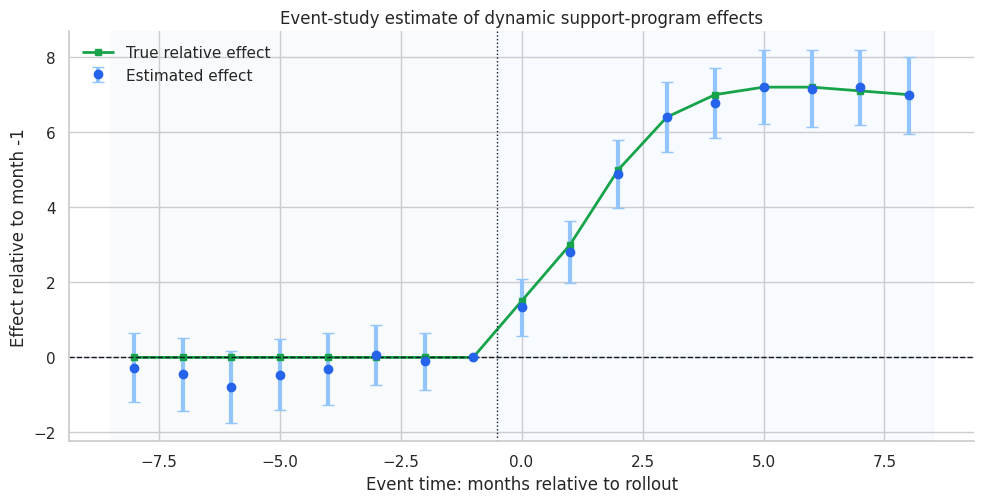

In [7]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def plot_event_study(table, title, subtitle=None, true_column="true_relative_effect"):
    """
    Plot event-time estimates with uncertainty bands and optional truth overlay.
    
    Idea:
        The display makes pre-trends, anticipation, and dynamic post-treatment effects easier to inspect than a coefficient table alone.
    
    Args:
        table: Coefficient table containing event-time estimates and intervals.
        title: Title displayed on the Graphviz or Matplotlib figure.
        subtitle: Additional explanatory text printed on the event-study figure.
        true_column: Optional column containing true effects to overlay on the event-study plot.
    
    Returns:
        tuple: Matplotlib figure and axes containing the event-study diagnostic plot.
    """
    plot_df = table.sort_values("event_time").copy()
    fig, ax = plt.subplots(figsize=(10, 5.2))

    ax.errorbar(
        plot_df["event_time"],
        plot_df["estimate"],
        yerr=[plot_df["estimate"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["estimate"]],
        fmt="o",
        color="#2563eb",
        ecolor="#93c5fd",
        elinewidth=3,
        capsize=4,
        label="Estimated effect",
    )
    ax.plot(
        plot_df["event_time"],
        plot_df[true_column],
        color="#16a34a",
        linewidth=2,
        marker="s",
        markersize=4,
        label="True relative effect",
    )
    ax.axhline(0, color="#111827", linewidth=1, linestyle="--")
    ax.axvline(-0.5, color="#111827", linewidth=1, linestyle=":")
    ax.axvspan(plot_df["event_time"].min() - 0.5, -0.5, color="#f8fafc", alpha=0.95, zorder=-1)
    ax.axvspan(-0.5, plot_df["event_time"].max() + 0.5, color="#eff6ff", alpha=0.45, zorder=-1)
    ax.set_xlabel("Event time: months relative to rollout")
    ax.set_ylabel("Effect relative to month -1")
    ax.set_title(title)
    if subtitle:
        ax.text(0.01, 0.98, subtitle, transform=ax.transAxes, va="top", ha="left", fontsize=10, color="#475569")
    ax.legend(frameon=False, loc="upper left")
    sns.despine(ax=ax)
    plt.tight_layout()
    return fig, ax


plot_event_study(event_table, "Event-study estimate of dynamic support-program effects");

This plot is the core event-study object.

The pre-period estimates are close to zero. That supports the idea that treated and comparison stores were moving similarly before rollout. The post-period estimates show a ramp-up: the immediate effect is modest, the effect grows over the next few months, and then it stabilizes.

This is why event studies are so valuable in industry. A single DiD estimate may say "the program worked." The event study says "the program needed about three months to reach most of its effect."


## 4. Leads, Lags, and the Omitted Period

With $k=-1$ omitted, the coefficient for $k=2$ means:

$$
\beta_2 =
\left[(\bar{Y}_{T,2} - \bar{Y}_{T,-1}) - (\bar{Y}_{C,2} - \bar{Y}_{C,-1})\right]
$$

It is not simply the treated-control difference at month 2. It is the treated-control difference at month 2 after subtracting the treated-control difference in the reference month.

That is why the omitted category should usually be a clean untreated period. The last pre-treatment period, $k=-1$, is common because it is close to rollout and often comparable to early post periods. But if teams changed behavior before the official launch, $k=-1$ may already be contaminated.


In [8]:
selected_months = event_table.loc[event_table["event_time"].isin([-4, -3, -2, -1, 0, 1, 2, 3, 6, 8])].copy()
selected_months[["event_time", "estimate", "ci_low", "ci_high", "p_value", "true_relative_effect"]]


,event_time,estimate,ci_low,ci_high,p_value,true_relative_effect
4,-4,-0.310,-1.258,0.638,0.522,0.000
5,-3,0.075,-0.725,0.876,0.854,0.000
6,-2,-0.107,-0.860,0.646,0.781,0.000
7,-1,0.000,0.000,0.000,NaN,0.000
8,0,1.331,0.570,2.092,0.001,1.500
9,1,2.817,1.989,3.646,0.000,3.000
10,2,4.887,3.981,5.794,0.000,5.000
11,3,6.414,5.481,7.347,0.000,6.400
14,6,7.160,6.129,8.191,0.000,7.200
16,8,6.984,5.953,8.015,0.000,7.000


The table version is useful for exact values, but the plot should usually lead the narrative. Event studies are visual diagnostics as much as regression output.


## 5. Joint Pre-Trend Test

Applied papers often report whether the pre-treatment leads are jointly different from zero. In this single-cohort design, we test:

$$
H_0: \beta_{-8}=\beta_{-7}=\cdots=\beta_{-2}=0
$$

We exclude $\beta_{-1}$ because it is the omitted reference period.


In [9]:
lead_terms = [column for column in event_columns if column.startswith("event_m") and column != "event_m1"]
pretrend_test = joint_test_summary(model, lead_terms, "Joint test of all estimated pre-rollout leads")
smart_display(pretrend_test)


,test,f_stat,p_value,df_num
0,Joint test of all estimated pre-rollout leads,0.577,0.774,7


In this valid simulation, the joint pre-trend test does not reject. That is reassuring, but the wording matters. The test leaves parallel trends as an assumption. It says the data did not detect pre-period deviations from the reference pattern.

Freyaldenhoven, Hansen, and Shapiro (2019) and Roth (2022) both caution against treating a non-rejected pre-trend test as a design guarantee. Pre-trend tests can have low power, and estimates selected after passing a pre-test can have distorted inference.


## 6. Average DiD Versus Dynamic Effects

Now compare the event-study path with the single average post-period DiD estimate. The average DiD regression is:

$$
Y_{it} = \alpha_i + \lambda_t + \tau(D_i \times Post_t) + \epsilon_{it}
$$

This collapses all post-rollout months into one number.


In [10]:
# Fit the Average DiD Versus Dynamic Effects model and collect the estimate needed below.
df_with_did = df.assign(did=lambda x: x["treated_region"] * x["post"])
average_did_model = smf.ols("revenue ~ did + C(store_id) + C(month)", data=df_with_did).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_with_did["store_id"]},
)

average_did_row = extract_parameter(average_did_model, "did").to_frame("average_post_DiD").T
average_did_row["true_average_post_effect"] = true_average_post_effect
smart_display(average_did_row)


,estimate,std_error,ci_low,ci_high,p_value,true_average_post_effect
average_post_DiD,5.929,0.264,5.412,6.446,0.000,5.711


In Average DiD Versus Dynamic Effects, the model output is also evidence about the trend assumption. Pre-period behavior is what makes the untreated counterfactual believable.

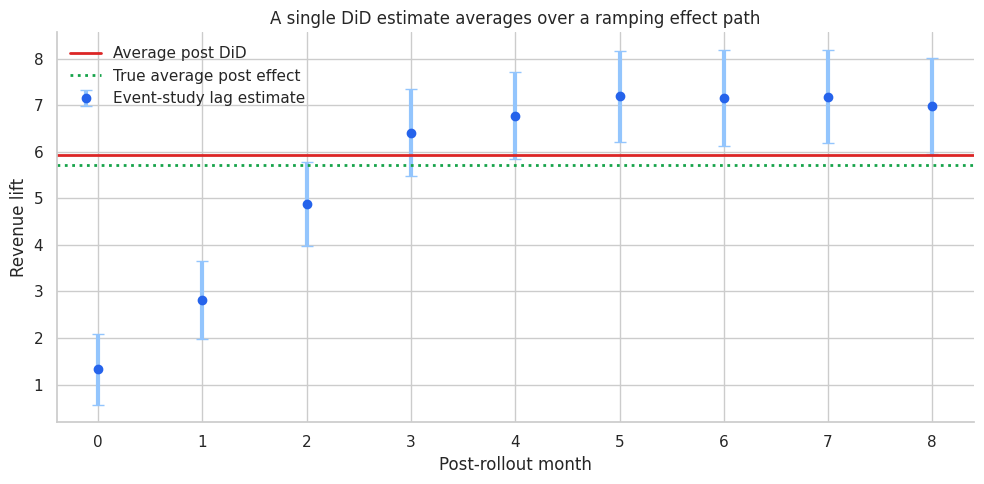

In [11]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, ax = plt.subplots(figsize=(10, 5.0))
post_table = event_table[event_table["event_time"] >= 0]
ax.errorbar(
    post_table["event_time"],
    post_table["estimate"],
    yerr=[post_table["estimate"] - post_table["ci_low"], post_table["ci_high"] - post_table["estimate"]],
    fmt="o",
    color="#2563eb",
    ecolor="#93c5fd",
    elinewidth=3,
    capsize=4,
    label="Event-study lag estimate",
)
ax.axhline(average_did_model.params["did"], color="#dc2626", linewidth=2, label="Average post DiD")
ax.axhline(true_average_post_effect, color="#16a34a", linewidth=2, linestyle=":", label="True average post effect")
ax.set_title("A single DiD estimate averages over a ramping effect path")
ax.set_xlabel("Post-rollout month")
ax.set_ylabel("Revenue lift")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()


The average DiD estimate is not wrong, but it hides the adoption curve. If the business decision is "should we continue this program for at least six months?", the ramp-up path is more informative than the average. If the decision is "what is the expected lift next quarter?", the later lags may be more relevant than the launch month.


## 7. Reference Period Choice

Event-study coefficients are relative to the omitted period. If we change the reference period, the plot shifts. The underlying data are the same, but the coefficient interpretation changes.

Below we compare the standard $k=-1$ reference to a less useful $k=0$ reference.


In [12]:
# Assemble the Reference Period Choice summary table used for interpretation.
_, event_table_ref0, _ = fit_event_study(df, reference=0)
comparison_reference = event_table.merge(
    event_table_ref0[["event_time", "estimate"]].rename(columns={"estimate": "estimate_reference_0"}),
    on="event_time",
)
comparison_reference = comparison_reference.rename(columns={"estimate": "estimate_reference_minus_1"})
comparison_reference.loc[comparison_reference["event_time"].isin([-2, -1, 0, 1, 2, 3]), [
    "event_time",
    "estimate_reference_minus_1",
    "estimate_reference_0",
    "true_relative_effect",
]]


,event_time,estimate_reference_minus_1,estimate_reference_0,true_relative_effect
6,-2,-0.107,-1.438,0.000
7,-1,0.000,-1.331,0.000
8,0,1.331,0.000,1.500
9,1,2.817,1.486,3.000
10,2,4.887,3.557,5.000
11,3,6.414,5.083,6.400


In Reference Period Choice, the table is also evidence about the trend assumption. If the pre-period comparison is weak, the treatment effect should be read cautiously.

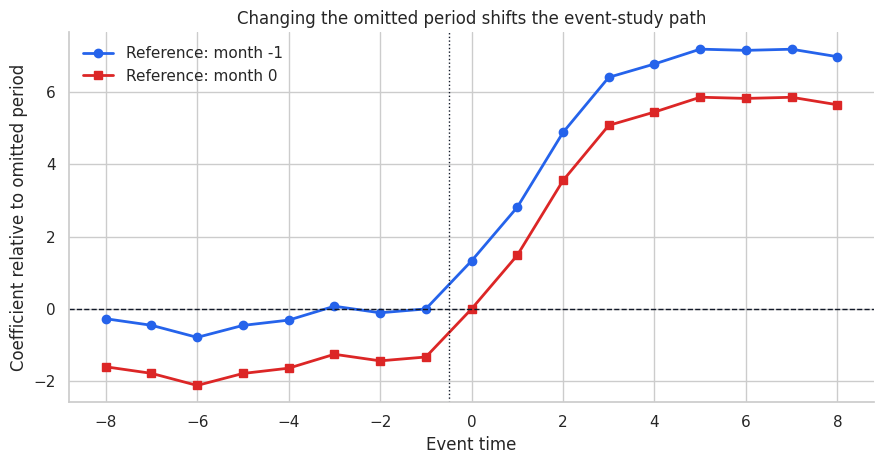

In [13]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(
    comparison_reference["event_time"],
    comparison_reference["estimate_reference_minus_1"],
    marker="o",
    linewidth=2,
    color="#2563eb",
    label="Reference: month -1",
)
ax.plot(
    comparison_reference["event_time"],
    comparison_reference["estimate_reference_0"],
    marker="s",
    linewidth=2,
    color="#dc2626",
    label="Reference: month 0",
)
ax.axhline(0, color="#111827", linewidth=1, linestyle="--")
ax.axvline(-0.5, color="#111827", linewidth=1, linestyle=":")
ax.set_title("Changing the omitted period shifts the event-study path")
ax.set_xlabel("Event time")
ax.set_ylabel("Coefficient relative to omitted period")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()


When month 0 is the reference, all coefficients are interpreted relative to launch month. That is rarely the cleanest baseline because launch month is already treated. For causal interpretation, a pre-treatment reference period is usually easier to defend.


## 8. Binning Event-Time Tails

Long panels often have sparse or noisy far-away event times. A common practice is to bin tails: for example, combine all months $k \le -6$ into one lead bin and all months $k \ge 6$ into one lag bin.

Binning reduces visual clutter and avoids over-interpreting thin tails. The tradeoff is that the endpoint bins become averages over multiple relative months.


In [14]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def add_binned_event_time(frame, low=-6, high=6):
    """Collapse event-time tails into endpoint bins for event-study robustness.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        low: Lower event-time bound for indicators or bins.
        high: Upper event-time bound for indicators or bins.

    Returns:
        pandas.DataFrame: Copy of the frame with binned event-time indicators.
    """
    work = frame.copy()
    work["event_time_binned"] = work["event_time"].clip(lower=low, upper=high)
    return work


def fit_binned_event_study(frame, low=-6, high=6, reference=-1):
    """Fit an event-study model after binning event-time tails.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        low: Lower event-time bound for indicators or bins.
        high: Upper event-time bound for indicators or bins.
        reference: Reference value or omitted event time used for interpretation.

    Returns:
        tuple: Fitted binned event-study model and coefficient table.
    """
    work = add_binned_event_time(frame, low=low, high=high)
    event_times = list(range(low, high + 1))
    event_columns = []
    for event_time in event_times:
        if event_time == reference:
            continue
        column = event_term(event_time)
        work[column] = (
            work["treated_region"].eq(1) & work["event_time_binned"].eq(event_time)
        ).astype(int)
        event_columns.append(column)

    formula = "revenue ~ " + " + ".join(event_columns) + " + C(store_id) + C(month)"
    model = smf.ols(formula, data=work).fit(
        cov_type="cluster",
        cov_kwds={"groups": work["store_id"]},
    )

    rows = []
    reference_effect = 0.0
    for event_time in event_times:
        if event_time == reference:
            rows.append({"event_time": event_time, "estimate": 0.0, "ci_low": 0.0, "ci_high": 0.0})
        else:
            term = event_term(event_time)
            ci_low, ci_high = model.conf_int().loc[term]
            rows.append({"event_time": event_time, "estimate": model.params[term], "ci_low": ci_low, "ci_high": ci_high})
    return model, pd.DataFrame(rows)


binned_model, binned_table = fit_binned_event_study(df)
binned_table.head()

,event_time,estimate,ci_low,ci_high
0,-6,-0.504,-1.338,0.330
1,-5,-0.456,-1.404,0.491
2,-4,-0.310,-1.258,0.638
3,-3,0.075,-0.725,0.876
4,-2,-0.107,-0.859,0.646


In Binning Event-Time Tails, the model output is also evidence about the trend assumption. The design claim lives in the pre-period comparison as much as in the coefficient.

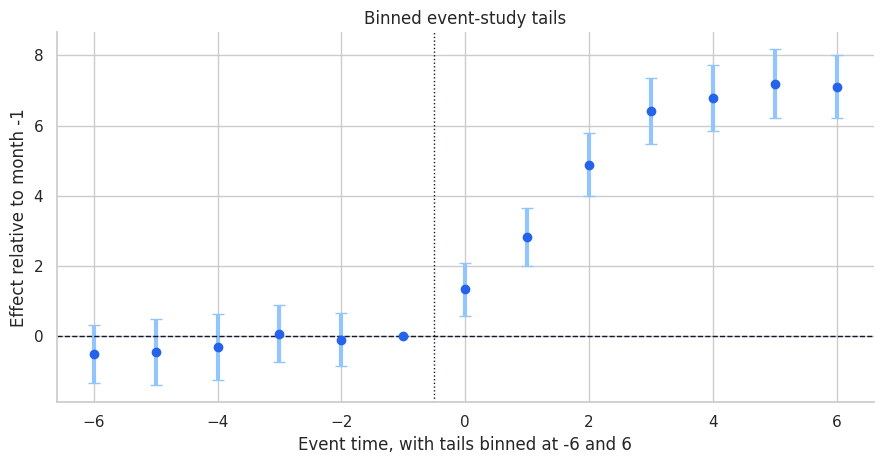

In [15]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.errorbar(
    binned_table["event_time"],
    binned_table["estimate"],
    yerr=[binned_table["estimate"] - binned_table["ci_low"], binned_table["ci_high"] - binned_table["estimate"]],
    fmt="o",
    color="#2563eb",
    ecolor="#93c5fd",
    elinewidth=3,
    capsize=4,
)
ax.axhline(0, color="#111827", linestyle="--", linewidth=1)
ax.axvline(-0.5, color="#111827", linestyle=":", linewidth=1)
ax.set_title("Binned event-study tails")
ax.set_xlabel("Event time, with tails binned at -6 and 6")
ax.set_ylabel("Effect relative to month -1")
sns.despine(ax=ax)
plt.tight_layout()


The endpoint at $k=6$ now includes all months 6, 7, and 8. The endpoint at $k=-6$ includes months -8, -7, and -6. Labeling this clearly prevents readers from treating binned endpoint estimates as single-month effects.


## 9. Failure Mode: Non-Parallel Pre-Trends

Now simulate a treated region that was already growing slightly faster before rollout. This is not caused by the support program. It is an untreated trend difference.

The event-study leads should warn us that the treated group was drifting relative to the comparison group before the intervention.


In [16]:
# Fit the statistical model and collect estimates used in the following interpretation.
df_nonparallel = simulate_event_study_panel(differential_trend=0.18, noise_scale=3.0)
nonparallel_model, nonparallel_table, nonparallel_columns = fit_event_study(df_nonparallel)
nonparallel_leads = [column for column in nonparallel_columns if column.startswith("event_m") and column != "event_m1"]
nonparallel_pretest = joint_test_summary(nonparallel_model, nonparallel_leads, "Joint pre-trend test under non-parallel trends")

nonparallel_average = df_nonparallel.assign(did=lambda x: x["treated_region"] * x["post"])
nonparallel_average_model = smf.ols("revenue ~ did + C(store_id) + C(month)", data=nonparallel_average).fit(
    cov_type="cluster",
    cov_kwds={"groups": nonparallel_average["store_id"]},
)
nonparallel_true_average = df_nonparallel.loc[
    df_nonparallel["treated_region"].eq(1) & df_nonparallel["post"].eq(1),
    "true_treatment_effect",
].mean()

pd.concat(
    [
        nonparallel_pretest,
        extract_parameter(nonparallel_average_model, "did").to_frame("average_DiD_under_nonparallel_trends").T.assign(
            true_average_post_effect=nonparallel_true_average,
            bias=lambda x: x["estimate"] - x["true_average_post_effect"],
        ),
    ],
    axis=0,
)


,test,f_stat,p_value,df_num,estimate,std_error,ci_low,ci_high,true_average_post_effect,bias
0,Joint pre-trend test under non-parallel trends,1.746,0.098,7.000,NaN,NaN,NaN,NaN,NaN,NaN
average_DiD_under_nonparallel_trends,NaN,NaN,0.000,NaN,7.453,0.321,6.823,8.082,5.711,1.742


In Failure Mode: Non-Parallel Pre-Trends, the model output is also evidence about the trend assumption. A convincing pre-period pattern is what lets the post-period gap carry causal weight.

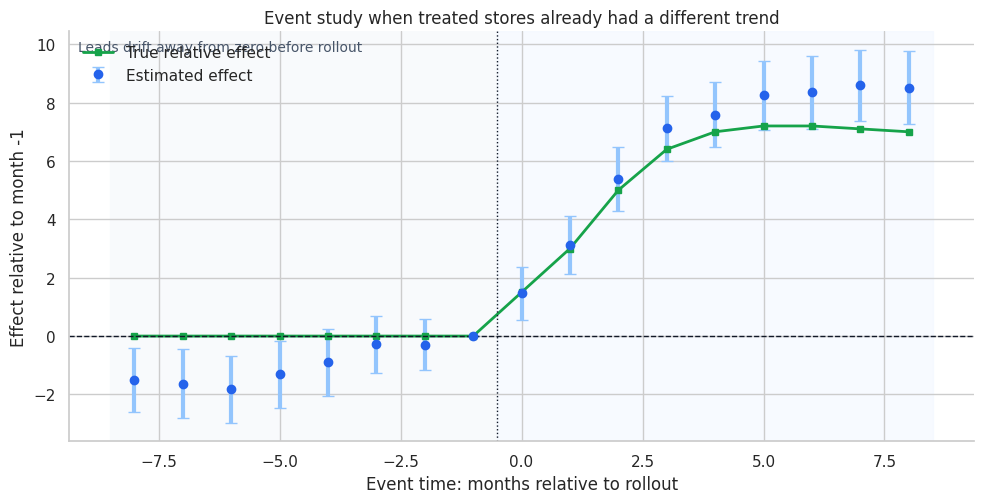

In [17]:
plot_event_study(
    nonparallel_table,
    "Event study when treated stores already had a different trend",
    subtitle="Leads drift away from zero before rollout",
);


The pre-period estimates are not flat. The simple event-study interpretation is no longer credible because the treated group was already moving differently. The post-period coefficients blend the program effect with the extrapolated continuation of that pre-existing trend.

This is a design problem. A regression with more decorative controls rarely solves the design problem by itself. Better responses include improving the comparison group, matching or weighting on pre-period outcomes, using a synthetic control design, or narrowing the claim.


## 10. Failure Mode: Anticipation and Reference-Period Contamination

Event-study leads can also move because the intervention affected behavior before the official start date. For example, stores might receive training, inventory, or customer lists two months before launch. That is not exactly a violation in the same sense as an unrelated pre-trend; it means the intervention bundle started earlier than the official date.

This creates a reference-period problem. If $k=-1$ is already affected, all coefficients are relative to a contaminated baseline.


In [18]:
# Assemble the Failure Mode: Anticipation and Reference-Period Contamination summary table used for interpretation.
df_anticipation = simulate_event_study_panel(anticipation=True)
anticipation_model_ref_minus1, anticipation_table_ref_minus1, _ = fit_event_study(df_anticipation, reference=-1)
anticipation_model_ref_minus3, anticipation_table_ref_minus3, _ = fit_event_study(df_anticipation, reference=-3)

anticipation_compare = anticipation_table_ref_minus1[["event_time", "estimate", "true_relative_effect"]].rename(
    columns={"estimate": "estimate_ref_minus1", "true_relative_effect": "true_ref_minus1"}
).merge(
    anticipation_table_ref_minus3[["event_time", "estimate", "true_relative_effect"]].rename(
        columns={"estimate": "estimate_ref_minus3", "true_relative_effect": "true_ref_minus3"}
    ),
    on="event_time",
)
anticipation_compare.loc[anticipation_compare["event_time"].between(-4, 3)]


,event_time,estimate_ref_minus1,true_ref_minus1,estimate_ref_minus3,true_ref_minus3
4,-4,-2.310,-2.000,-0.385,0.000
5,-3,-1.925,-2.000,0.000,0.000
6,-2,-0.907,-0.800,1.018,1.200
7,-1,0.000,0.000,1.925,2.000
8,0,-0.669,-0.500,1.255,1.500
9,1,0.817,1.000,2.742,3.000
10,2,2.887,3.000,4.812,5.000
11,3,4.414,4.400,6.338,6.400


In Failure Mode: Anticipation and Reference-Period Contamination, the model output is also evidence about the trend assumption. Pre-period behavior is what makes the untreated counterfactual believable.

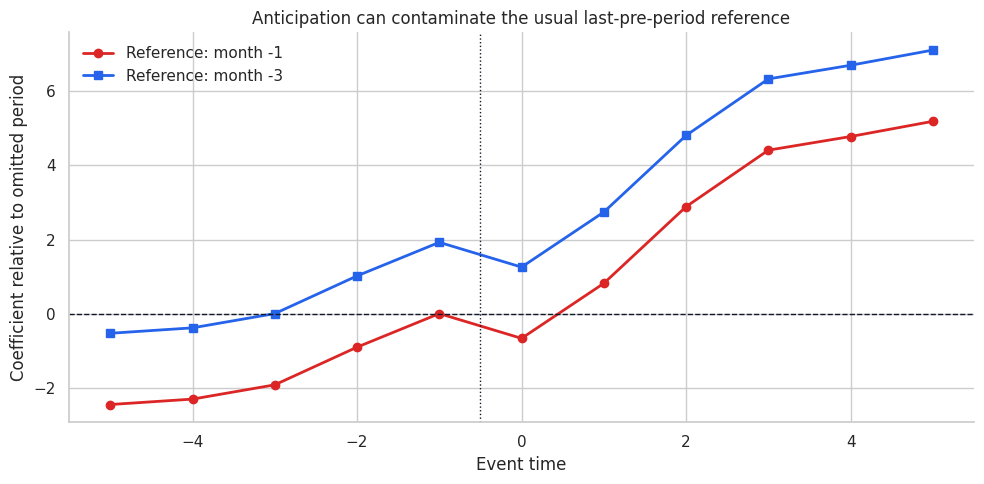

In [19]:
# Build the Failure Mode: Anticipation and Reference-Period Contamination plot from the quantities computed above.
fig, ax = plt.subplots(figsize=(10, 5.0))
window = anticipation_compare[anticipation_compare["event_time"].between(-5, 5)]
ax.plot(window["event_time"], window["estimate_ref_minus1"], marker="o", linewidth=2, color="#dc2626", label="Reference: month -1")
ax.plot(window["event_time"], window["estimate_ref_minus3"], marker="s", linewidth=2, color="#2563eb", label="Reference: month -3")
ax.axhline(0, color="#111827", linestyle="--", linewidth=1)
ax.axvline(-0.5, color="#111827", linestyle=":", linewidth=1)
ax.set_title("Anticipation can contaminate the usual last-pre-period reference")
ax.set_xlabel("Event time")
ax.set_ylabel("Coefficient relative to omitted period")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()


With $k=-1$ as the reference, the launch-month estimate can look too small because the baseline already contains part of the intervention effect. With an earlier clean reference, the anticipatory months become visible.

The practical lesson is simple: do not choose the omitted pre-period mechanically. Ask when behavior could have changed. The relevant event may be announcement, training, enforcement, customer exposure, or full technical launch.


## 11. Event-Study Inference

Event-study regressions have many coefficients, and the coefficients are correlated with each other. Three habits help keep the interpretation disciplined:

- Cluster standard errors at the treatment-assignment or unit level appropriate for the design.
- Do not over-interpret one noisy lead or lag in isolation.
- Report the pre-period as a diagnostic, not as a certificate of validity.

Bertrand, Duflo, and Mullainathan (2004) show that serial correlation can make DiD standard errors misleading when ignored. The same concern applies to event-study panels because each unit contributes repeated observations over time.


In [20]:
# Assemble the Event-Study Inference summary table used for interpretation.
event_model_iid = smf.ols(
    "revenue ~ " + " + ".join(event_columns) + " + C(store_id) + C(month)",
    data=add_event_dummies(df)[0],
).fit()

event_model_cluster = model

inference_compare = pd.DataFrame(
    {
        "iid_SE_month_3": [event_model_iid.bse["event_p3"]],
        "clustered_SE_month_3": [event_model_cluster.bse["event_p3"]],
        "estimate_month_3": [event_model_cluster.params["event_p3"]],
    }
)
smart_display(inference_compare)


,iid_SE_month_3,clustered_SE_month_3,estimate_month_3
0,0.473,0.476,6.414


The point estimate is the same; the uncertainty changes. In real panel data, clustering choices should follow the treatment assignment and error-correlation structure, not whatever produces the smallest interval.


## 12. Industry Readout Template

An event-study readout should answer a different set of questions from a single DiD estimate:

- **When did the intervention plausibly begin?** Announcement, training, launch, enforcement, or customer exposure.
- **What is the omitted period?** Explain why it is an untreated baseline.
- **Are pre-period estimates close to zero?** Show the plot and report the joint test, but do not claim proof.
- **What is the effect path?** Immediate, delayed, ramping, decaying, persistent, or reversal.
- **Which window maps to the decision?** First month, first quarter, steady state, cumulative lift, or payback period.
- **What concurrent changes could explain the pattern?** Especially any treated-group shocks at or before rollout.
- **What should happen next?** Scale, pause, extend observation window, redesign comparison group, or run an experiment.


In [21]:
# Build the summary table used to connect the calculation back to the design question.
steady_state_window = event_table[event_table["event_time"].between(4, 8)]
first_quarter_window = event_table[event_table["event_time"].between(0, 2)]

readout = pd.DataFrame(
    {
        "Item": [
            "Reference period",
            "Pre-period diagnostic",
            "Launch effect",
            "First-quarter average",
            "Steady-state average",
            "Average post DiD",
            "Decision implication",
        ],
        "Example entry": [
            "Month -1, the last observed month before official rollout",
            f"Joint lead test p-value {pretrend_test.loc[0, 'p_value']:.3f}; visual leads near zero",
            f"Month 0 lift {event_table.loc[event_table['event_time'].eq(0), 'estimate'].iloc[0]:.2f}",
            f"Months 0-2 average lift {first_quarter_window['estimate'].mean():.2f}",
            f"Months 4-8 average lift {steady_state_window['estimate'].mean():.2f}",
            f"Single post-period DiD estimate {average_did_model.params['did']:.2f}",
            "Use the steady-state estimate for scale planning; do not judge the program only by launch month",
        ],
    }
)
smart_display(readout)


,Item,Example entry
0,Reference period,"Month -1, the last observed month before offic..."
1,Pre-period diagnostic,Joint lead test p-value 0.774; visual leads ne...
2,Launch effect,Month 0 lift 1.33
3,First-quarter average,Months 0-2 average lift 3.01
4,Steady-state average,Months 4-8 average lift 7.06
5,Average post DiD,Single post-period DiD estimate 5.93
6,Decision implication,Use the steady-state estimate for scale planni...


## Key Takeaways

- Event studies are dynamic DiD models with relative-time leads and lags.
- The omitted period defines the baseline for every coefficient.
- Leads are useful diagnostics for pre-trends and anticipation, but non-rejection is not proof of validity.
- Lags show whether effects are immediate, delayed, ramping, persistent, or fading.
- A single average DiD estimate can hide a substantively important effect path.
- If the last pre-period may be contaminated by announcement or preparation, choose an earlier clean reference and explain it.
- Event-study plots should be paired with a design narrative about timing, comparison groups, concurrent shocks, and the decision window.


## References

Bertrand, M., Duflo, E., & Mullainathan, S. (2004). How much should we trust differences-in-differences estimates? *The Quarterly Journal of Economics, 119*(1), 249-275. https://doi.org/10.1162/003355304772839588

Callaway, B. (2022). Difference-in-differences for policy evaluation. *arXiv*. https://doi.org/10.48550/arXiv.2203.15646

Freyaldenhoven, S., Hansen, C., & Shapiro, J. M. (2019). Pre-event trends in the panel event-study design. *American Economic Review, 109*(9), 3307-3338. https://doi.org/10.1257/aer.20180609

Roth, J. (2022). Pretest with caution: Event-study estimates after testing for parallel trends. *American Economic Review: Insights, 4*(3), 305-322. https://doi.org/10.1257/aeri.20210236

Ryan, A. M. (2018). Now trending: Coping with non-parallel trends in difference-in-differences analysis. *Statistical Methods in Medical Research, 28*(12), 3697-3711. https://doi.org/10.1177/0962280218814570
